# Ejercicio 9 - Mapas predictivos

Se calculan probabilidades para cada observación y se reconstruyen mapas sobre la rejilla de 50 metros.

## 0. Verificación del trabajo previo (gate)

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src.interpretabilidad import verificar as verificar_interpretabilidad

verificar_interpretabilidad()
print('Gate previo correcto.')

Gate previo correcto.


## 1-4. Probabilidades, rejilla y escala

Los intervalos son muy baja [0, 0.25), baja [0.25, 0.50), alta [0.50, 0.75) y muy alta [0.75, 1]. El umbral de clasificación es 0.50.

492663 probabilidades; rango 0.000000 a 0.999999


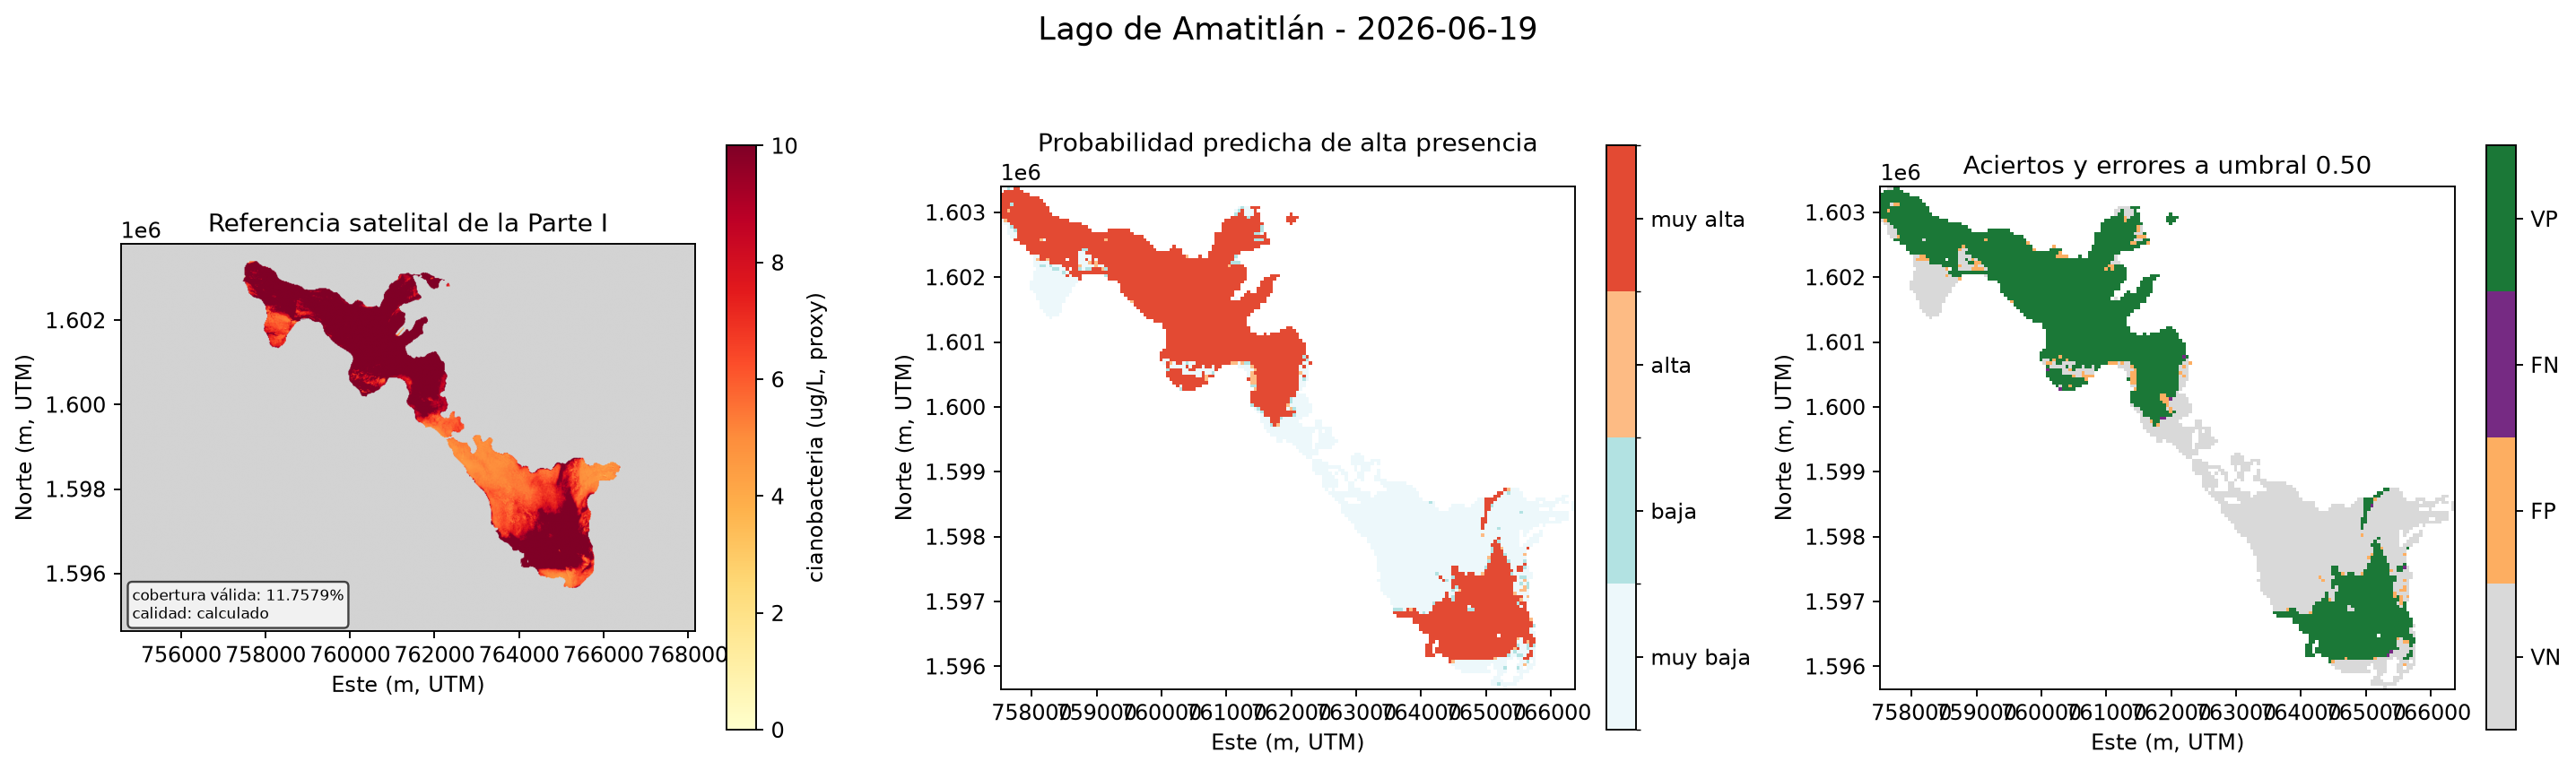

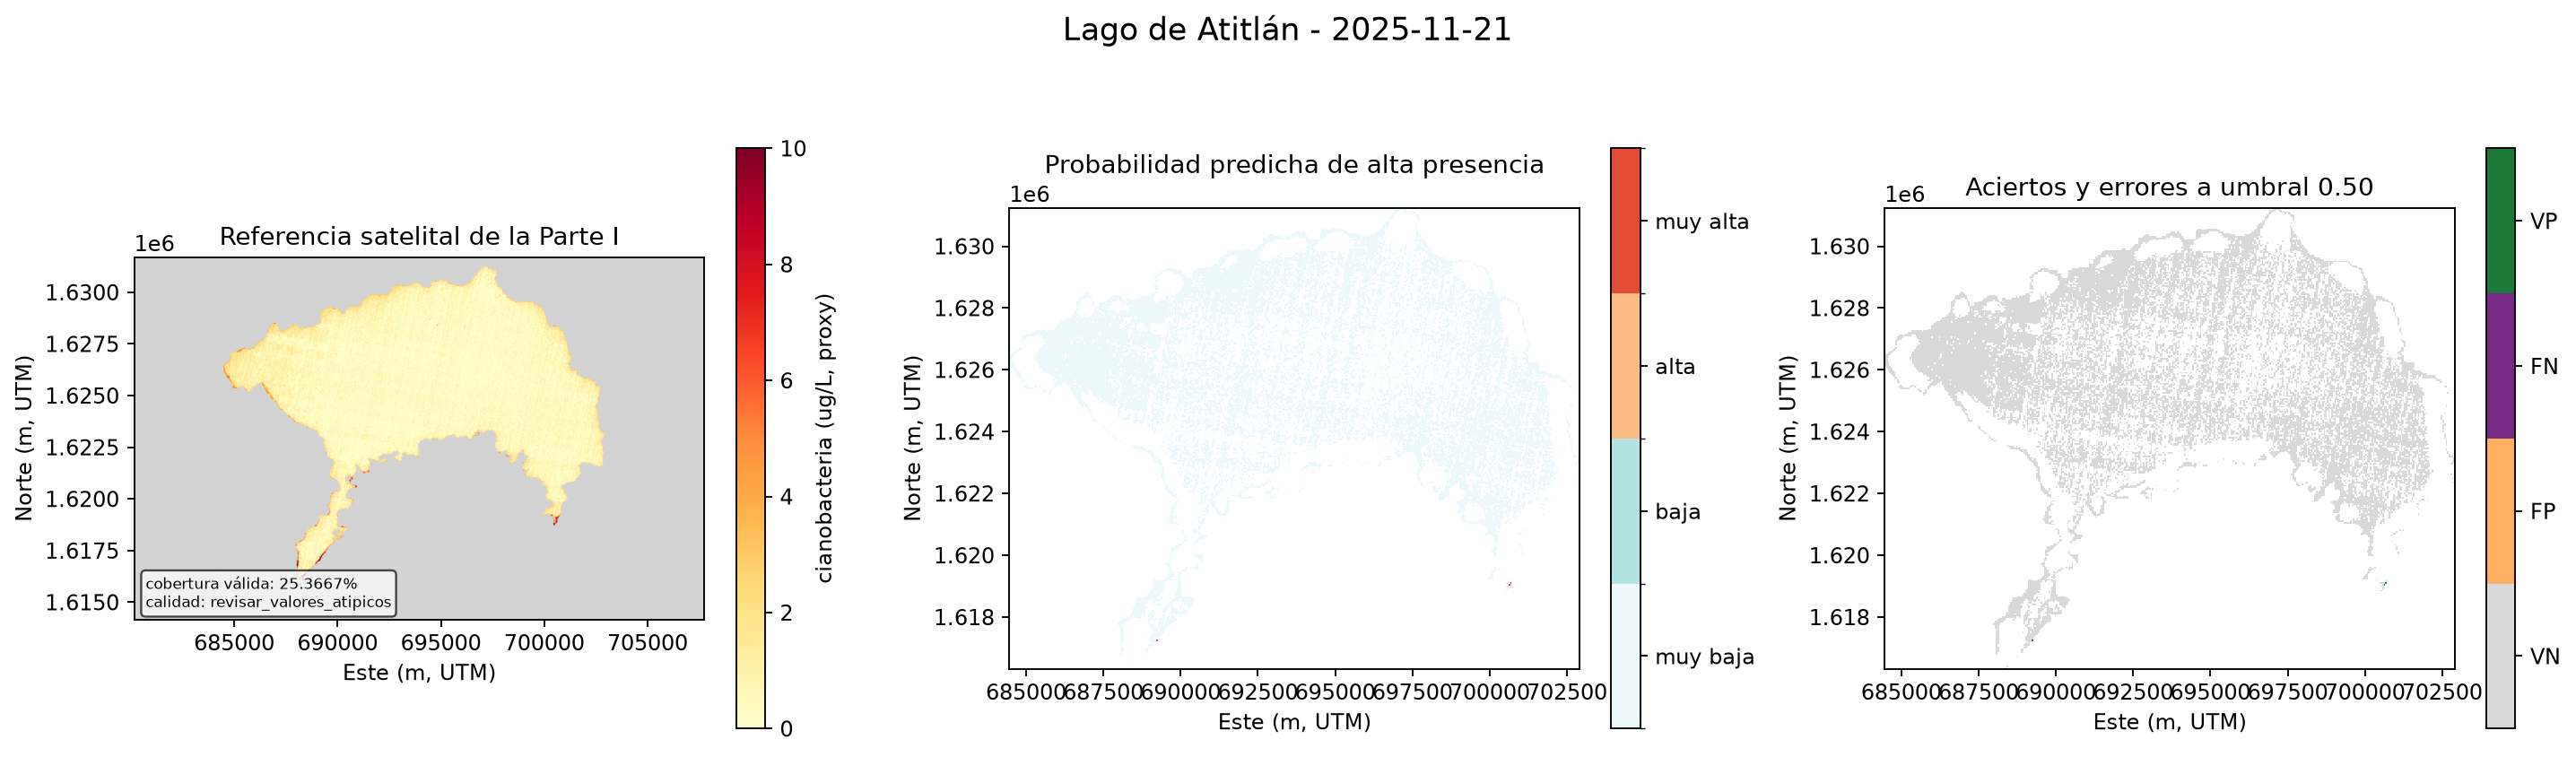

In [2]:
from src.mapas_predictivos import generar, verificar

resumen = generar()
verificar()
print(f"{resumen['observaciones']} probabilidades; rango {resumen['probabilidad_min']:.6f} a {resumen['probabilidad_max']:.6f}")
for mapa in resumen['mapas']:
    display(Image(filename=str(mapa)))

## 5-7. Comparación con la Parte 1 y errores espaciales

Cada figura compara el índice satelital, la probabilidad y las categorías VN, FP, FN y VP. El diagnóstico usa únicamente la partición de prueba.

In [3]:
errores = pd.read_csv(ROOT / 'results' / 'tables' / 'errores_espaciales.csv')
resumen_zona = errores.groupby(['lago', 'zona'])[['n_prueba', 'falsos_positivos', 'falsos_negativos']].sum()
display(resumen_zona)
display(errores.sort_values('tasa_error', ascending=False).head(10))

n_prueba  falsos_positivos  falsos_negativos
lago      zona                                                              
amatitlan interior_mas_1000m          18                 0                 0
          intermedia_250_1000m      8586                61                19
          orilla_0_250m             9657               166                27
atitlan   interior_mas_1000m       71895                 0                 0
          intermedia_250_1000m     40534                 0                 0
          orilla_0_250m            17109                 1                 0

,lago,fecha,zona,n_prueba,positivos_reales,probabilidad_media,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos,tasa_error,tasa_falsos_positivos,tasa_falsos_negativos
32,amatitlan,2026-06-19,orilla_0_250m,848,426,0.568717,364,58,6,420,0.075472,0.137441,0.014085
8,amatitlan,2025-04-28,orilla_0_250m,886,95,0.171440,740,51,2,93,0.059819,0.064475,0.021053
29,amatitlan,2026-04-28,orilla_0_250m,785,297,0.395502,467,21,6,291,0.034395,0.043033,0.020202
26,amatitlan,2026-04-13,orilla_0_250m,942,63,0.085518,859,20,6,57,0.027601,0.022753,0.095238
7,amatitlan,2025-04-28,intermedia_250_1000m,816,35,0.064728,763,18,4,31,0.026961,0.023047,0.114286
31,amatitlan,2026-06-19,intermedia_250_1000m,779,499,0.658759,265,15,4,495,0.024390,0.053571,0.008016
28,amatitlan,2026-04-28,intermedia_250_1000m,755,229,0.311251,519,7,3,226,0.013245,0.013308,0.0131
13,amatitlan,2026-01-08,intermedia_250_1000m,818,52,0.071395,758,8,2,50,0.012225,0.010444,0.038462
23,amatitlan,2026-03-29,orilla_0_250m,904,64,0.076101,834,6,4,60,0.011062,0.007143,0.0625
25,amatitlan,2026-04-13,intermedia_250_1000m,774,12,0.014219,759,3,5,7,0.010336,0.003937,0.416667


Los errores de Amatitlán se concentran cerca de la orilla, donde también se concentra la señal positiva y existen transiciones entre agua y costa. La prueba de Atitlán no contiene positivos, por lo que no permite estimar falsos negativos en ese lago; solo registra un falso positivo.